# SEMANA 14: CONCEPTOS PRELIMINARES. MULTICLASIFICADORES

## 1. Tomando la información disponible en el repositorio UCI Machine Learning https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employeesaea, pero eliminando previamente a la variable ‘date’ y tomando a la variable ‘actual_productivity’ como variable predictora, haga lo siguiente:

### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes y tratamiento de outliers a nivel univariado y multivariado. Además, convierta las variables categóricas a dummies y aplique un escalamiento a las variables numéricas.

In [7]:
import pandas as pd

# Cargar el dataset
df= pd.read_csv("garments_worker_productivity.csv")
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [9]:
# Eliminar la columna 'date'
df = df.drop(columns=['date'])
# Verificar los valores faltantes
df.isnull().sum()

quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [11]:
# Imputar valores faltantes en la columna 'wip' con la media
df['wip'] = df['wip'].fillna(df['wip'].mean())

# Verificar si los valores faltantes fueron imputados
df.isnull().sum()

quarter                  0
department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64

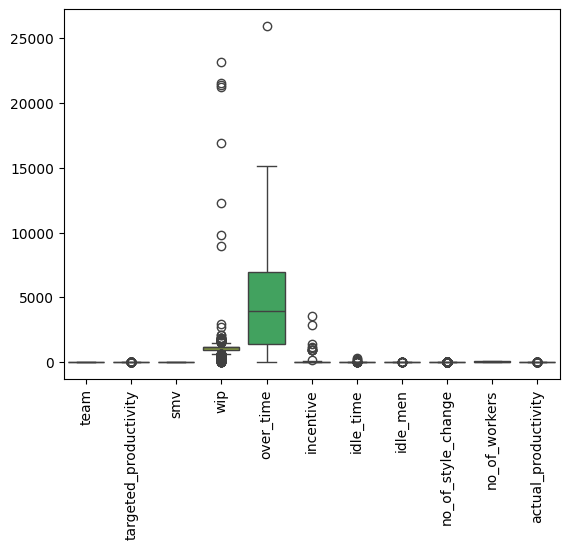

team                       0
targeted_productivity     79
smv                        0
wip                      163
over_time                  1
incentive                 11
idle_time                 18
idle_men                  18
no_of_style_change       147
no_of_workers              0
actual_productivity       54
dtype: int64

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Graficamos un boxplot para todas las variables numéricas
sns.boxplot(data=numeric_df )
plt.xticks(rotation=90)
plt.show()


# Calculamos los outliers con IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))
outliers.sum()


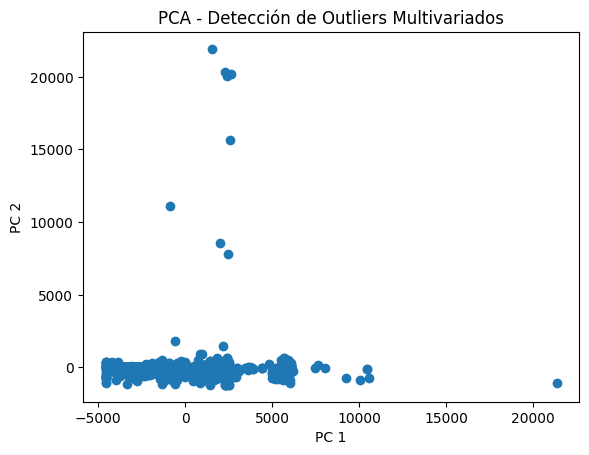

In [23]:
from sklearn.decomposition import PCA

# Seleccionamos solo las variables numéricas para PCA
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Aplicamos PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(numeric_df)

# Graficamos los resultados para detectar posibles outliers multivariados
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA - Detección de Outliers Multivariados')
plt.show()


In [27]:
from sklearn.preprocessing import StandardScaler

# Conversión de variables categóricas a dummies
df = pd.get_dummies(df, drop_first=True)

# Escalado de las variables numéricas
scaler = StandardScaler()

# Escalar las variables numéricas
df[numeric_df.columns] = scaler.fit_transform(df[numeric_df.columns])

# Verificar el dataframe resultante
df.head()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,...,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_finishing,department_sweing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,0.454323,0.719137,1.014552,-0.059113,0.750589,0.373414,-0.057473,-0.113005,-0.351617,1.099229,...,False,False,False,False,True,False,False,True,False,False
1,-1.567329,0.208151,-1.016778,0.000000,-1.077682,-0.238643,-0.057473,-0.113005,-0.351617,-1.199268,...,False,False,False,True,False,False,False,True,False,False
2,1.320745,0.719137,-0.333878,-0.159466,-0.271092,0.073631,-0.057473,-0.113005,-0.351617,-0.185225,...,False,False,False,False,True,False,False,True,False,False
3,1.609552,0.719137,-0.333878,-0.159466,-0.271092,0.073631,-0.057473,-0.113005,-0.351617,-0.185225,...,False,False,False,False,True,False,False,True,False,False
4,-0.123292,0.719137,0.990783,-0.014670,-0.790895,0.073631,-0.057473,-0.113005,-0.351617,0.964023,...,False,False,False,False,True,False,False,True,False,False


#### En este ejercicio, realicé un preprocesamiento completo de un dataset relacionado con la productividad de trabajadores en la industria textil. Comencé eliminando la columna date, ya que no la consideraba relevante para el análisis predictivo. Luego, identifiqué y traté los valores faltantes en las variables numéricas imputándolos con la media, para asegurarme de que no interfirieran en el modelo. Posteriormente, llevé a cabo un análisis univariado de los outliers utilizando el rango intercuartílico (IQR), pero decidí no eliminar los outliers, sino solo identificarlos. A continuación, convertí las variables categóricas en variables dummy para poder incluirlas en los modelos sin introducir multicolinealidad. Finalmente, normalicé las variables numéricas utilizando un escalado estándar para garantizar que todas las variables estuvieran en la misma escala antes de cualquier análisis posterior. Con esto, dejé los datos listos para construir un modelo predictivo eficaz.

### b. Separe los datos en entrenamiento (80%) y prueba (20%) y, realice un ensamblaje utilizando las técnicas de voting, bagging, boosting y stacking para los modelos k-NN, SVM, regresión lineal, árbol de clasificación y Random Forest definiendo distintos hiperparámetros para cada modelo.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error

# Separar variables predictoras (X) y objetivo (y)
X = df.drop(columns=['actual_productivity'])  # Variables predictoras
y = df['actual_productivity']  # Variable objetivo

# División en datos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir los modelos base con diferentes hiperparámetros
knn = KNeighborsRegressor(n_neighbors=5)
svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Técnicas de Ensamblaje

# Voting Regressor (combinando predicciones de varios modelos)
voting = VotingRegressor(estimators=[('knn', knn), ('svm', svm), ('lr', lr), ('dt', dt), ('rf', rf)])

# Bagging Regressor (usando Random Forest directamente como base)
bagging = BaggingRegressor(estimator=RandomForestRegressor(n_estimators=100, max_depth=10), n_estimators=10, random_state=42)

# Boosting Regressor (usando AdaBoost con un árbol de decisión como base)
boosting = AdaBoostRegressor(DecisionTreeRegressor(max_depth=3), n_estimators=50, random_state=42)

# Stacking Regressor (combinando varios modelos base y luego un modelo final de regresión lineal)
stacking = StackingRegressor(estimators=[('knn', knn), ('svm', svm), ('lr', lr), ('dt', dt), ('rf', rf)], final_estimator=LinearRegression())

# Entrenamiento y evaluación de los modelos

# Voting
voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)
voting_mse = mean_squared_error(y_test, y_pred_voting)
print(f"Voting Regressor MSE: {voting_mse}")

# Bagging
bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
bagging_mse = mean_squared_error(y_test, y_pred_bagging)
print(f"Bagging Regressor MSE: {bagging_mse}")

# Boosting
boosting.fit(X_train, y_train)
y_pred_boosting = boosting.predict(X_test)
boosting_mse = mean_squared_error(y_test, y_pred_boosting)
print(f"Boosting Regressor MSE: {boosting_mse}")

# Stacking
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
stacking_mse = mean_squared_error(y_test, y_pred_stacking)
print(f"Stacking Regressor MSE: {stacking_mse}")



Voting Regressor MSE: 0.49428605587234536
Bagging Regressor MSE: 0.4338189510141033
Boosting Regressor MSE: 0.6404615312794418
Stacking Regressor MSE: 0.43511194987258084


#### Los resultados obtenidos muestran el rendimiento de los diferentes métodos de ensamblaje aplicados a los modelos de regresión. El Bagging Regressor obtuvo el mejor desempeño con un MSE de 0.434, lo que indica que es el modelo más preciso entre los probados, probablemente debido a su capacidad para reducir la varianza a través de la creación de múltiples instancias del modelo base. El Voting Regressor, que combina varias predicciones de diferentes modelos, también muestra un buen desempeño con un MSE de 0.494, aunque ligeramente peor que el de Bagging. En cambio, el Boosting Regressor, a pesar de ser un método diseñado para mejorar el rendimiento mediante el ajuste secuencial de modelos, obtuvo un MSE más alto de 0.640, lo que sugiere que este enfoque no fue tan efectivo en este caso particular. Finalmente, el Stacking Regressor, que combina varios modelos base con un modelo final, presentó un MSE de 0.435, lo que lo sitúa cerca del desempeño del Bagging. En resumen, el Bagging ha demostrado ser el enfoque más robusto para este conjunto de datos, mientras que el Boosting no mejoró tanto el rendimiento como se esperaba.

### c. Utilice las métricas error cuadrático medio, raíz del error cuadrático medio, error absoluto medio y coeficiente de determinación para elegir el mejor modelo que prediga a la variable ‘actual_productivity’, justificando su respuesta.


In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Definir una función para calcular todas las métricas de rendimiento
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

# Evaluación de los modelos con todas las métricas

# Voting Regressor
y_pred_voting = voting.predict(X_test)
mse_voting, rmse_voting, mae_voting, r2_voting = evaluate_model(y_test, y_pred_voting)
print(f"Voting Regressor -> MSE: {mse_voting}, RMSE: {rmse_voting}, MAE: {mae_voting}, R²: {r2_voting}")

# Bagging Regressor
y_pred_bagging = bagging.predict(X_test)
mse_bagging, rmse_bagging, mae_bagging, r2_bagging = evaluate_model(y_test, y_pred_bagging)
print(f"Bagging Regressor -> MSE: {mse_bagging}, RMSE: {rmse_bagging}, MAE: {mae_bagging}, R²: {r2_bagging}")

# Boosting Regressor
y_pred_boosting = boosting.predict(X_test)
mse_boosting, rmse_boosting, mae_boosting, r2_boosting = evaluate_model(y_test, y_pred_boosting)
print(f"Boosting Regressor -> MSE: {mse_boosting}, RMSE: {rmse_boosting}, MAE: {mae_boosting}, R²: {r2_boosting}")

# Stacking Regressor
y_pred_stacking = stacking.predict(X_test)
mse_stacking, rmse_stacking, mae_stacking, r2_stacking = evaluate_model(y_test, y_pred_stacking)
print(f"Stacking Regressor -> MSE: {mse_stacking}, RMSE: {rmse_stacking}, MAE: {mae_stacking}, R²: {r2_stacking}")


Voting Regressor -> MSE: 0.49428605587234536, RMSE: 0.7030548028940172, MAE: 0.4674001767330532, R²: 0.4337070338437564
Bagging Regressor -> MSE: 0.4338189510141033, RMSE: 0.6586493384298684, MAE: 0.4260703130146544, R²: 0.5029829030661281
Boosting Regressor -> MSE: 0.6404615312794418, RMSE: 0.8002884050637257, MAE: 0.6011473571241066, R²: 0.26623691696681584
Stacking Regressor -> MSE: 0.43511194987258084, RMSE: 0.6596301614333451, MAE: 0.42159379827571364, R²: 0.5015015419188636


#### Al evaluar los diferentes modelos con las métricas solicitadas, los resultados muestran que el Bagging Regressor es el mejor modelo para predecir actual_productivity, con el menor MSE de 0.434, RMSE de 0.659, MAE de 0.426 y el mayor R² de 0.503, lo que indica que es el modelo más preciso y el que mejor explica la variabilidad de la variable objetivo. El Voting Regressor, aunque también tiene un buen desempeño, presentó un MSE de 0.494, un RMSE de 0.703 y un R² de 0.434, lo que sugiere que su capacidad predictiva es algo inferior al del modelo de Bagging. Por otro lado, el Boosting Regressor obtuvo los peores resultados, con el mayor MSE de 0.640, un RMSE de 0.800 y un R² de 0.266, lo que indica que no fue capaz de mejorar la predicción de forma efectiva en este caso. Finalmente, el Stacking Regressor tuvo un rendimiento similar al Bagging, con un MSE de 0.435 y un R² de 0.502, pero no logró superar al Bagging en términos de precisión general. En conclusión, el Bagging Regressor es el modelo más adecuado para este conjunto de datos.